🧬 Step 1 — Simulate a Gene Expression Dataset

In [9]:
import pandas as pd
import numpy as np

# Define neural genes
genes = ["MAP2", "NEUROD1", "SYP", "ENO2", "GFAP", "NTRK1", "MBP", "TUBB3"]

# Create sample labels
samples = ["Norm_1", "Norm_2", "Norm_3", "Tum_1", "Tum_2", "Tum_3"]

# Simulate expression counts (higher in normal for some genes)
np.random.seed(42)
data = {
    gene: np.concatenate([
        np.random.poisson(lam=np.random.randint(50, 100), size=3),  # Normal
        np.random.poisson(lam=np.random.randint(20, 50), size=3)    # Tumor
    ])
    for gene in genes
}

df = pd.DataFrame(data, index=samples)
df = df.T  # Genes as rows
print(df)

         Norm_1  Norm_2  Norm_3  Tum_1  Tum_2  Tum_3
MAP2         97      96      86     37     33     25
NEUROD1      73      71      63     42     51     51
SYP          90      80      91     30     24     22
ENO2         80      64      57     40     37     31
GFAP         66      83      80     33     32     23
NTRK1        76      74      73     38     35     34
MBP          52      63      69     25     22     23
TUBB3        54      40      45     50     59     39


🎨 Step 2 — Apply PCA

In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Transpose: samples as rows, genes as features
X = df.T.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create DataFrame for plotting
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["Group"] = ["Normal"] * 3 + ["Tumor"] * 3

🧪 Step 3 — Visualize PCA result

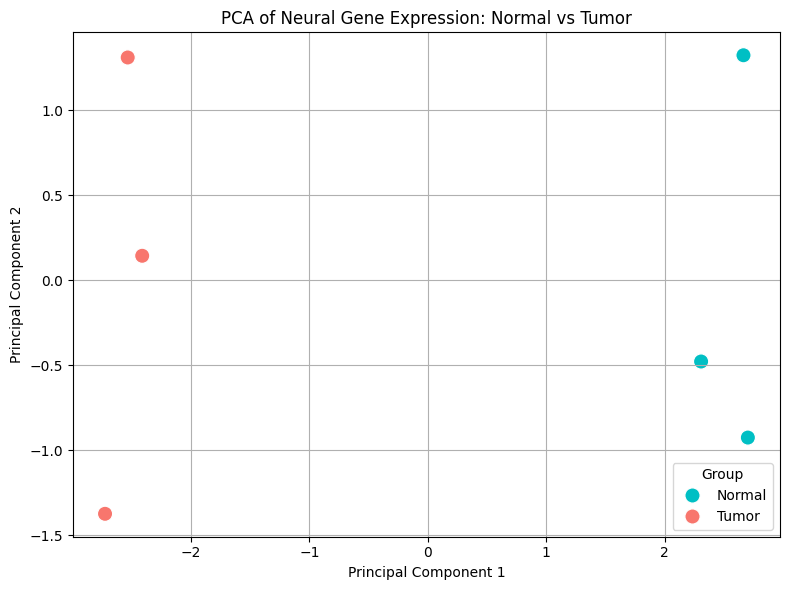

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="Group", s=120, palette=["#00BFC4", "#F8766D"])
plt.title("PCA of Neural Gene Expression: Normal vs Tumor")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()

🧠 What PCA Reveals
- PCA reduces the 8-dimensional gene space to 2D, capturing the most variance.
- If neural genes are differentially expressed, PCA will show clear separation between normal and tumor samples.
- You can extend this to real datasets from TCGA, GEO, or use tools like scanpy for single-cell RNA-Seq.
